In [63]:
import pandas as pd
import requests
pd.set_option('display.max_columns', None)

#### Get the Ticker and CIK Id mapping

In [41]:
# create request header
headers = {'User-Agent': "email@address.com"}

# get all companies data
companyTickers = requests.get(
    "https://www.sec.gov/files/company_tickers.json",
    headers=headers
    )

# review response / keys
# companyTickers.json()
# for k,v in companyTickers.json().items():
#     print(v['ticker'], v['cik_str'], v['title'])

data = [v for k,v in companyTickers.json().items()]
df = pd.DataFrame(data)

# OR
# df = pd.DataFrame.from_dict(companyTickers.json(), orient='index')

df["cik_str"] = df["cik_str"].astype(str).str.zfill(10).apply(lambda x: f"CIK{x}")
df

,cik_str,ticker,title
0,CIK0001045810,NVDA,NVIDIA CORP
1,CIK0001652044,GOOGL,Alphabet Inc.
2,CIK0000320193,AAPL,Apple Inc.
3,CIK0000789019,MSFT,MICROSOFT CORP
4,CIK0001018724,AMZN,AMAZON COM INC
...,...,...,...
10421,CIK0001937737,MLECW,Moolec Science SA
10422,CIK0001936258,NAMSW,NewAmsterdam Pharma Co N.V.
10423,CIK0001937987,FBYDP,"Falcon's Beyond Global, Inc."
10424,CIK0001937987,FBYDW,"Falcon's Beyond Global, Inc."


#### Get the filing data

In [47]:
# get company specific filing metadata
cik = 'CIK0001937737'
filingMetadata = requests.get(
    f'https://data.sec.gov/submissions/{cik}.json',
    headers=headers
    )
data = filingMetadata.json()
data

{'cik': '0001937737',
 'entityType': 'other',
 'sic': '2000',
 'sicDescription': 'Food and Kindred Products',
 'ownerOrg': '04 Manufacturing',
 'insiderTransactionForOwnerExists': 0,
 'insiderTransactionForIssuerExists': 1,
 'name': 'Moolec Science SA',
 'tickers': ['MLEC', 'MLECW'],
 'exchanges': ['Nasdaq', 'Nasdaq'],
 'ein': '000000000',
 'lei': None,
 'description': '',
 'website': '',
 'investorWebsite': '',
 'category': 'Non-accelerated filer<br>Emerging growth company',
 'fiscalYearEnd': '0630',
 'stateOfIncorporation': 'E9',
 'stateOfIncorporationDescription': 'Cayman Islands',
 'addresses': {'mailing': {'street1': '89 NEXUS WAY, CAMANA BAY',
   'street2': None,
   'city': 'GRAND CAYMAN',
   'stateOrCountry': None,
   'zipCode': 'KY1-9009',
   'stateOrCountryDescription': None,
   'isForeignLocation': 1,
   'foreignStateTerritory': None,
   'country': 'Cayman Islands',
   'countryCode': 'E9'},
  'business': {'street1': '89 NEXUS WAY, CAMANA BAY',
   'street2': None,
   'city': '

In [60]:
list(data['filings']['recent']['primaryDocument'])

['ea0293192-6k_moolec.htm',
 'ea0290902-6k_moolec.htm',
 'ea0290616-6k_moolec.htm',
 'ea0290711-6k_moolec.htm',
 'ea0286539-6k_moolec.htm',
 'xslF345X06/ownership.xml',
 'xslSCHEDULE_13D_X02/primary_doc.xml',
 'xslSCHEDULE_13D_X02/primary_doc.xml',
 'ea0284916-6k_moolec.htm',
 'xslF345X06/ownership.xml',
 'xslF345X06/ownership.xml',
 'xslF345X06/ownership.xml',
 'xslF345X06/ownership.xml',
 'xslF345X06/ownership.xml',
 'xslF345X06/ownership.xml',
 'xslF345X06/ownership.xml',
 'xslF345X06/ownership.xml',
 'ea0278490-6k_moolec.htm',
 'ea0274930-6k_moolec.htm',
 'ea0274004-6k_moolec.htm',
 'ea0273730-6k_moolec.htm',
 'ea0271949-6k_moolec.htm',
 'ea0271492-6k_moolec.htm',
 'ea0271382-6k_moolec.htm',
 'ea0270125-20f_moolec.htm',
 'ea0269987-6k_moolec.htm',
 'ea0269586-6k_moolec.htm',
 'ea0267674-6k_moolec.htm',
 'ea0266431-6k_moolec.htm',
 'ea0263368-nt20f_moolec.htm',
 'ea0262038-6k_moolec.htm',
 'ea0256935-6k_moolec.htm',
 'ea0253961-424b3_moolec.htm',
 'xslEFFECTX01/primary_doc.xml',
 'e

In [64]:
# dictionary to dataframe
allForms = pd.DataFrame.from_dict(
             filingMetadata.json()['filings']['recent']
             )
allForms

,accessionNumber,filingDate,reportDate,acceptanceDateTime,act,form,fileNumber,filmNumber,items,core_type,size,isXBRL,isInlineXBRL,isXBRLNumeric,primaryDocument,primaryDocDescription
0,0001213900-26-063814,2026-06-02,2026-06-02,2026-06-02T12:45:20.000Z,34,6-K,001-41586,261053748,,6-K,13336,0,0,0.0,ea0293192-6k_moolec.htm,REPORT OF FOREIGN PRIVATE ISSUER
1,0001213900-26-056658,2026-05-14,2026-05-14,2026-05-14T20:20:41.000Z,34,6-K,001-41586,26979315,,6-K,16516,0,0,0.0,ea0290902-6k_moolec.htm,REPORT OF FOREIGN PRIVATE ISSUER
2,0001213900-26-056140,2026-05-14,2026-05-13,2026-05-14T01:17:17.000Z,34,6-K,001-41586,26975460,,6-K,896033,0,0,0.0,ea0290616-6k_moolec.htm,REPORT OF FOREIGN PRIVATE ISSUER
3,0001213900-26-055949,2026-05-13,2026-05-13,2026-05-13T21:19:20.000Z,34,6-K,001-41586,26974651,,6-K,48957,0,0,0.0,ea0290711-6k_moolec.htm,REPORT OF FOREIGN PRIVATE ISSUER
4,0001213900-26-044117,2026-04-15,2026-04-15,2026-04-15T20:47:52.000Z,34,6-K,001-41586,26864689,,6-K,42325,0,0,0.0,ea0286539-6k_moolec.htm,REPORT OF FOREIGN PRIVATE ISSUER
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
167,0001213900-22-059361,2022-09-27,,2022-09-27T19:04:08.000Z,33,DRS/A,377-06316,221270607,,DRS/A,11161936,0,0,NaN,filename1.htm,
168,0000000000-22-009785,2022-09-08,,2022-09-08T18:30:04.000Z,,UPLOAD,,,,LETTER,64038,0,0,NaN,filename1.pdf,
169,0000000000-22-008651,2022-08-15,,2022-08-15T14:27:20.000Z,,UPLOAD,,,,LETTER,224862,0,0,NaN,filename1.pdf,
170,0001213900-22-047460,2022-08-12,,2022-08-12T20:41:51.000Z,,DRSLTR,,,,DRSLTR,8693,0,0,NaN,filename1.htm,


In [65]:
# review columns
allForms.columns
allForms[['accessionNumber', 'reportDate', 'form']].head(50)

,accessionNumber,reportDate,form
0,0001213900-26-063814,2026-06-02,6-K
1,0001213900-26-056658,2026-05-14,6-K
2,0001213900-26-056140,2026-05-13,6-K
3,0001213900-26-055949,2026-05-13,6-K
4,0001213900-26-044117,2026-04-15,6-K
5,0001213900-26-044029,2026-04-15,3
6,0001683168-26-002746,,SCHEDULE 13D/A
7,0001683168-26-002703,,SCHEDULE 13D
8,0001213900-26-039184,2026-04-02,6-K
9,0001213900-26-031970,2026-02-06,3


In [73]:
# get company facts data
companyFacts = requests.get(
    f'https://data.sec.gov/api/xbrl/companyfacts/{cik}.json',
    headers=headers
    )
companyFacts.json()['facts']['us-gaap']

{'FinancialInstrumentSubjectToMandatoryRedemptionParValuePerShare': {'label': 'Financial Instrument Subject to Mandatory Redemption, Par Value Per Share',
  'description': 'Par value per share of mandatory redeemable financial instrument classified as liability.',
  'units': {'USD/shares': [{'end': '2022-12-31',
     'val': 0.01,
     'accn': '0001213900-23-025842',
     'fy': 2023,
     'fp': 'Q2',
     'form': '6-K',
     'filed': '2023-04-03',
     'frame': 'CY2022Q4I'}]}},
 'BusinessAcquisitionsProFormaRevenue': {'label': 'Business Acquisition, Pro Forma Revenue',
  'description': 'The pro forma revenue for a period as if the business combination or combinations had been completed at the beginning of the period.',
  'units': {'USD': [{'start': '2022-07-01',
     'end': '2023-06-30',
     'val': 5043956,
     'accn': '0001213900-23-081591',
     'fy': 2023,
     'fp': 'FY',
     'form': '20-F',
     'filed': '2023-10-30'},
    {'start': '2022-07-01',
     'end': '2023-06-30',
     '

In [74]:
companyFacts.json()['facts']['dei'][
    'EntityCommonStockSharesOutstanding']

{'label': 'Entity Common Stock, Shares Outstanding',
 'description': "Indicate number of shares or other units outstanding of each of registrant's classes of capital or common stock or other ownership interests, if and as stated on cover of related periodic report. Where multiple classes or units exist define each class/interest by adding class of stock items such as Common Class A [Member], Common Class B [Member] or Partnership Interest [Member] onto the Instrument [Domain] of the Entity Listings, Instrument.",
 'units': {'shares': [{'end': '2023-06-30',
    'val': 37563768,
    'accn': '0001213900-23-081591',
    'fy': 2023,
    'fp': 'FY',
    'form': '20-F',
    'filed': '2023-10-30'},
   {'end': '2023-06-30',
    'val': 37563768,
    'accn': '0001213900-23-082664',
    'fy': 2023,
    'fp': 'FY',
    'form': '20-F/A',
    'filed': '2023-11-02',
    'frame': 'CY2023Q2I'},
   {'end': '2024-06-30',
    'val': 38440602,
    'accn': '0001213900-24-092168',
    'fy': 2024,
    'fp': 'F

In [77]:
# different amounts of data available per concept

companyFacts.json()['facts']['us-gaap']

{'FinancialInstrumentSubjectToMandatoryRedemptionParValuePerShare': {'label': 'Financial Instrument Subject to Mandatory Redemption, Par Value Per Share',
  'description': 'Par value per share of mandatory redeemable financial instrument classified as liability.',
  'units': {'USD/shares': [{'end': '2022-12-31',
     'val': 0.01,
     'accn': '0001213900-23-025842',
     'fy': 2023,
     'fp': 'Q2',
     'form': '6-K',
     'filed': '2023-04-03',
     'frame': 'CY2022Q4I'}]}},
 'BusinessAcquisitionsProFormaRevenue': {'label': 'Business Acquisition, Pro Forma Revenue',
  'description': 'The pro forma revenue for a period as if the business combination or combinations had been completed at the beginning of the period.',
  'units': {'USD': [{'start': '2022-07-01',
     'end': '2023-06-30',
     'val': 5043956,
     'accn': '0001213900-23-081591',
     'fy': 2023,
     'fp': 'FY',
     'form': '20-F',
     'filed': '2023-10-30'},
    {'start': '2022-07-01',
     'end': '2023-06-30',
     '

In [85]:
cik = 'CIK0000320193'

In [97]:
# get company concept data
companyConcept = requests.get(
    f'https://data.sec.gov/api/xbrl/companyconcept/{cik}/us-gaap/Assets.json',
    headers=headers
    )
pd.DataFrame.from_dict(companyConcept.json()['units']['USD'])

,end,val,accn,fy,fp,form,filed,frame
0,2008-09-27,39572000000,0001193125-09-153165,2009.0,Q3,10-Q,2009-07-22,NaN
1,2008-09-27,39572000000,0001193125-09-214859,2009.0,FY,10-K,2009-10-27,NaN
2,2008-09-27,36171000000,0001193125-10-012091,2009.0,FY,10-K/A,2010-01-25,NaN
3,2008-09-27,36171000000,0001193125-10-238044,2010.0,FY,10-K,2010-10-27,CY2008Q3I
4,2009-06-27,48140000000,0001193125-09-153165,2009.0,Q3,10-Q,2009-07-22,CY2009Q2I
...,...,...,...,...,...,...,...,...
139,2025-09-27,359241000000,0000320193-25-000079,2025.0,FY,10-K,2025-10-31,NaN
140,2025-09-27,359241000000,0000320193-26-000006,2026.0,Q1,10-Q,2026-01-30,NaN
141,2025-09-27,359241000000,0000320193-26-000013,2026.0,Q2,10-Q,2026-05-01,CY2025Q3I
142,2025-12-27,379297000000,0000320193-26-000006,2026.0,Q1,10-Q,2026-01-30,CY2025Q4I


In [99]:
# get all filings data 
assetsData = pd.DataFrame.from_dict((
               companyConcept.json()['units']['USD']))
assetsData

,end,val,accn,fy,fp,form,filed,frame
0,2008-09-27,39572000000,0001193125-09-153165,2009.0,Q3,10-Q,2009-07-22,NaN
1,2008-09-27,39572000000,0001193125-09-214859,2009.0,FY,10-K,2009-10-27,NaN
2,2008-09-27,36171000000,0001193125-10-012091,2009.0,FY,10-K/A,2010-01-25,NaN
3,2008-09-27,36171000000,0001193125-10-238044,2010.0,FY,10-K,2010-10-27,CY2008Q3I
4,2009-06-27,48140000000,0001193125-09-153165,2009.0,Q3,10-Q,2009-07-22,CY2009Q2I
...,...,...,...,...,...,...,...,...
139,2025-09-27,359241000000,0000320193-25-000079,2025.0,FY,10-K,2025-10-31,NaN
140,2025-09-27,359241000000,0000320193-26-000006,2026.0,Q1,10-Q,2026-01-30,NaN
141,2025-09-27,359241000000,0000320193-26-000013,2026.0,Q2,10-Q,2026-05-01,CY2025Q3I
142,2025-12-27,379297000000,0000320193-26-000006,2026.0,Q1,10-Q,2026-01-30,CY2025Q4I


In [100]:
# review data
assetsData.columns
assetsData.form

0        10-Q
1        10-K
2      10-K/A
3        10-K
4        10-Q
        ...  
139      10-K
140      10-Q
141      10-Q
142      10-Q
143      10-Q
Name: form, Length: 144, dtype: str

Resolved 112 packages in 518ms                                       
Prepared 6 packages in 2.17s                                             
Installed 7 packages in 21ms                                
 + contourpy==1.3.3
 + cycler==0.12.1
 + fonttools==4.63.0
 + kiwisolver==1.5.0
 + matplotlib==3.11.0
 + pillow==12.3.0
 + pyparsing==3.3.2


Matplotlib is building the font cache; this may take a moment.


<Axes: xlabel='end'>

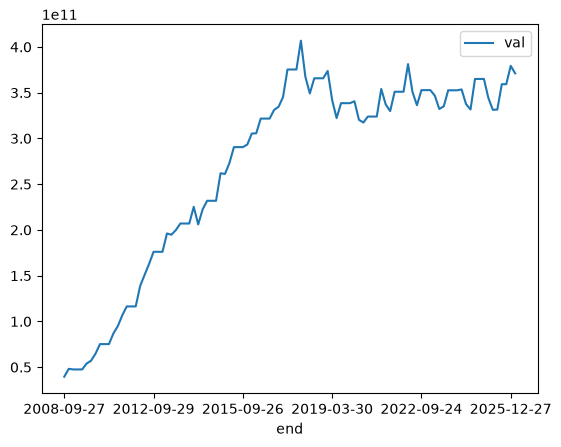

In [104]:
!uv add matplotlib
# from matplotlib import pyplot as plt
# get assets from 10Q forms and reset index
assets10Q = assetsData[assetsData.form == '10-Q']
assets10Q = assets10Q.reset_index(drop=True)

# plot 
assets10Q.plot(x='end', y='val')

In [107]:
# get company concept data
res = requests.get(
    f'https://www.sec.gov/Archives/edgar/daily-index/2025/QTR3/company20251001.json',
    headers=headers
    )
res.status_code

403

In [108]:
import requests                                                                                                  
headers = {                                                                                                      
  "User-Agent": "AURUM-Project rkbettereveryday@gmail.com",  # ← must have name + email                               
  "Accept-Encoding": "gzip, deflate",                                                                          
  "Host": "www.sec.gov"                                                                                        
}                                                                                                                
url = "https://www.sec.gov/Archives/edgar/daily-index/2025/QTR3/company20250701.json"                            
resp = requests.get(url, headers=headers)                                                                        
print(resp.status_code)

403
